# 2. Neural model selection and artifact export

This notebook is independently runnable. It recreates the seeded train and validation folds, fits preprocessing on train only, documents TCN trainability, compares three network architectures with persistent Optuna studies, and saves every validation-selected model with its operating threshold. The hold-out test is deliberately not read or evaluated here; that one-time comparison is isolated in Notebook 03.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from deeplearning_examples.io import load_data
from burst_detection.artifacts import save_holdout_manifest
from burst_detection.data import (
    fit_archetype_bank, fit_preprocessor, generate_dataset_splits, targets_to_tensor,
)
from burst_detection.metrics import select_threshold
from burst_detection.model import BurstTCN, count_parameters, create_burst_model
from burst_detection.training import (
    TrainingConfig, artifact_root, predict_probabilities,
    set_reproducible_seed, train_model,
)
from burst_detection.tuning import (
    BurstOptunaConfig, best_burst_model_configs, burst_trial_frame,
    optuna_parameter_importances, run_burst_model_search,
)
from burst_detection.visualization import plot_training_history

In [2]:
SPLIT_CONFIG = {"train_size": 800, "validation_size": 200, "test_size": 200, "random_seed": 42}
ARCHETYPE_SEED = 42

experimental_train, doses, _ = load_data("train")
archetypes = fit_archetype_bank(
    experimental_train[doses == "100pM"], random_seed=ARCHETYPE_SEED,
)
splits = generate_dataset_splits(archetypes=archetypes, **SPLIT_CONFIG)

preprocessor = fit_preprocessor(splits.train.signals, include_derivative=True)
train_x = preprocessor.transform(splits.train.signals)
validation_x = preprocessor.transform(splits.validation.signals)
train_y = targets_to_tensor(splits.train.labels)
validation_y = targets_to_tensor(splits.validation.labels)
train_x.shape, train_y.shape, preprocessor

(torch.Size([800, 2, 289]),
 torch.Size([800, 289]),
 TrajectoryPreprocessor(signal_mean=0.9036475047143568, signal_std=0.3166881353211856, derivative_mean=0.001426770955511082, derivative_std=0.03210822099706068, include_derivative=True))

## Tiny-batch memorization check

A reduced TCN is fitted to only eight trajectories while the untouched validation fold remains the comparison curve. Successful trainability appears as a strong decrease in tiny-batch training loss. A growing separation from validation loss is expected in this diagnostic because its purpose is to demonstrate memorization capacity, not generalization. The full history documents the behavior directly instead of reducing it to a Boolean assertion.

epoch   1: train loss 0.9303, validation loss 0.6496, AP 0.763
epoch  30: train loss 0.1012, validation loss 0.4328, AP 0.913
epoch  60: train loss 0.0163, validation loss 0.6210, AP 0.894
epoch  90: train loss 0.0034, validation loss 0.7596, AP 0.883
epoch 120: train loss 0.0016, validation loss 0.8131, AP 0.884


initial_train_loss          0.930337
final_train_loss            0.001613
minimum_validation_loss     0.377036
best_validation_epoch      13.000000
Name: memorization diagnostic, dtype: float64

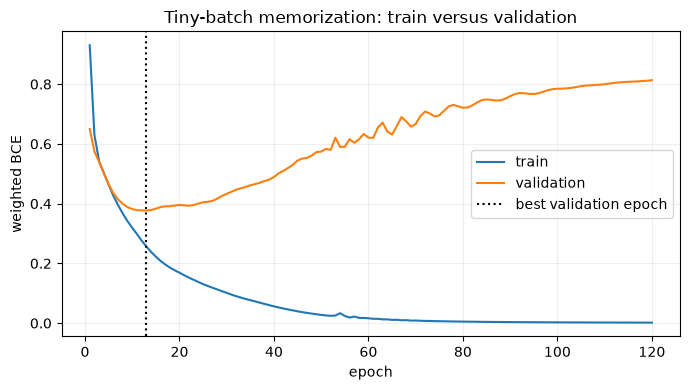

In [3]:
SANITY_SAMPLES = 8
set_reproducible_seed(7)
sanity_model = BurstTCN(
    input_channels=train_x.shape[1], hidden_channels=16,
    dilations=(1, 2, 4, 8), dropout=0.0,
)
sanity_history = train_model(
    sanity_model, train_x[:SANITY_SAMPLES], train_y[:SANITY_SAMPLES],
    validation_x, validation_y,
    config=TrainingConfig(
        epochs=120, batch_size=SANITY_SAMPLES, learning_rate=3e-3,
        weight_decay=0.0, patience=120, random_seed=7, report_every=30,
    ),
)
plot_training_history(
    sanity_history, title="Tiny-batch memorization: train versus validation",
);
pd.Series({
    "initial_train_loss": sanity_history.training_loss[0],
    "final_train_loss": sanity_history.training_loss[-1],
    "minimum_validation_loss": min(sanity_history.validation_loss),
    "best_validation_epoch": sanity_history.best_epoch,
}, name="memorization diagnostic")

### Interpretation

The diagnostic is successful when the training loss on eight trajectories approaches a very small value while validation loss reaches its minimum earlier and subsequently stagnates or rises. That divergence is intentional evidence that the implementation and optimization path can memorize aligned dense targets. It is not evidence of useful generalization and therefore does not determine the final architecture or stopping epoch. Small numerical differences between CPU and GPU runs are expected because floating-point reductions and some kernels differ; the qualitative divergence and conclusion should remain unchanged.

## Architectures and training objective

All candidates are length-preserving dense segmenters: an input with shape `(batch, 2, 289)` produces one burst logit for each of the 289 time points. The two channels are the standardized raw trajectory and its standardized first difference. No architecture pools over time.

### Dilated residual TCN

A **Temporal Convolutional Network (TCN)** processes a sequence with one-dimensional convolutions. The reference stack uses residual blocks with exponentially increasing dilations `1, 2, 4, 8, 16, 32`. Every block contains two same-padded convolutions, `GroupNorm`, `GELU`, dropout, and a skip connection. If $x$ is the block input and $F_d$ its two-convolution path at dilation $d$, the output is $\mathrm{GELU}(x + F_d(x))$.

Dilation spaces kernel taps apart and increases temporal context without pooling. For kernel size $k$ and dilation sequence $d$, the theoretical receptive field is $R = 1 + 2(k-1)\sum_d d$. The six-block reference with $k=5$ therefore has $R=505$, larger than the 289-sample trajectory. Symmetric padding makes this implementation non-causal: offline predictions may use observations before and after a time point. Residual connections provide short gradient paths through the deep stack.

### Local CNN

The CNN uses ordinary same-padded convolutions without dilation or residual skips. Its receptive field grows linearly as $R = 1 + L(k-1)$ for depth $L$. It is a deliberately local alternative: comparable performance would indicate that the exponentially expanded TCN context is unnecessary for this benchmark. A performance gap would support the value of multi-scale temporal context.

### Bidirectional GRU

The BiGRU reads the trajectory in both temporal directions and concatenates the forward and backward hidden states before pointwise classification. Its recurrent state has no fixed finite local receptive field, so every output can encode long-range sequential context. It offers an architecture contrast to convolutional models, although recurrence is less parallel during training and its bidirectionality also restricts it to offline detection.

Training uses weighted binary cross-entropy. `positive_weight='auto'` derives the negative-to-positive ratio from the train fold and applies the tuned cap, counteracting the dominance of background points. Minimum validation loss controls early stopping and checkpoint restoration; validation average precision is the threshold-free Optuna objective.

## Persistent per-architecture Optuna searches

Separate studies tune architecture-specific capacity together with dropout, learning rate, optional weight decay, batch size, positive-class-weight cap, and gradient clipping. Every trial uses the same train/validation split and initialization seed. The TCN study retains its original name and total budget of 20 trials, so completed runs remain available. The two added architecture studies use 12 total trials each. Re-execution only adds missing trials to the SQLite database; it does not repeat completed trials. Test labels and test probabilities never participate in selection.

In [4]:
ARCHITECTURES = ("tcn", "cnn", "bigru")
OPTUNA_TOTAL_TRIALS = {"tcn": 20, "cnn": 12, "bigru": 12}
study_db_path = (artifact_root() / "burst_tcn_optuna.db").resolve()
study_db_path.parent.mkdir(parents=True, exist_ok=True)

studies = {}
for architecture in ARCHITECTURES:
    studies[architecture] = run_burst_model_search(
        architecture, train_x, train_y, validation_x, validation_y,
        base_training_config=TrainingConfig(
            epochs=40, patience=8, random_seed=42, report_every=20,
        ),
        config=BurstOptunaConfig(
            n_trials=OPTUNA_TOTAL_TRIALS[architecture], n_trials_mode="total",
            study_name=f"burst-{architecture}-joint-v1",
            storage=f"sqlite:///{study_db_path}",
            sampler_seed=42, trial_seed=42,
            n_startup_trials=5, pruning_warmup_epochs=8,
        ),
    )

/home/lorenz/Environments/DeeplearningExamples/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-09-13 23:27:04,587] Using an existing study with name 'burst-tcn-joint-v1' instead of creating a new one.
[I 2026-09-13 23:27:04,653] Using an existing study with name 'burst-cnn-joint-v1' instead of creating a new one.
[I 2026-09-13 23:27:04,705] Using an existing study with name 'burst-bigru-joint-v1' instead of creating a new one.


epoch   1: train loss 0.7133, validation loss 0.6709, AP 0.729
epoch  20: train loss 0.1817, validation loss 0.1797, AP 0.983


[I 2026-09-13 23:27:11,231] Trial 11 finished with value: 0.985166272296969 and parameters: {'model.dropout': 0.3, 'model.hidden_size': 48, 'model.num_layers': 2, 'training.use_weight_decay': True, 'training.batch_size': 64, 'training.learning_rate': 0.0021914469472126626, 'training.weight_decay': 1.113741490829352e-06, 'training.maximum_positive_weight': 20.0, 'training.gradient_clip_norm': 2.0}. Best is trial 11 with value: 0.985166272296969.


epoch  40: train loss 0.1648, validation loss 0.1697, AP 0.985


## Trial analysis

Validation AP is the optimization target; validation loss, best epoch, and parameter count provide complementary information about convergence and capacity. The curves show completed trials and the best value available after each trial. Parameter importance describes associations learned within each study and should not be interpreted as a causal effect of changing one hyperparameter in isolation.

,trial,state,architecture,validation_ap,best_epoch,validation_loss,parameter_count,model.block_count,model.hidden_channels,model.kernel_size,model.dropout,training.use_weight_decay,training.batch_size,training.learning_rate,training.maximum_positive_weight,training.gradient_clip_norm,training.weight_decay,model.depth,model.hidden_size,model.num_layers
0,11,COMPLETE,tcn,0.9871,13.0,0.1585,140161.0,6.0,48.0,5.0,0.10,True,32,0.0026,10.0,1.0,0.0007,NaN,NaN,NaN
1,14,COMPLETE,tcn,0.9871,13.0,0.1587,140161.0,6.0,48.0,5.0,0.10,True,32,0.0029,10.0,1.0,0.0008,NaN,NaN,NaN
2,12,COMPLETE,tcn,0.9871,13.0,0.1588,140161.0,6.0,48.0,5.0,0.10,True,32,0.0029,10.0,1.0,0.0010,NaN,NaN,NaN
3,13,COMPLETE,tcn,0.9871,13.0,0.1593,140161.0,6.0,48.0,5.0,0.10,True,32,0.0030,10.0,1.0,0.0010,NaN,NaN,NaN
4,6,COMPLETE,tcn,0.9869,26.0,0.1598,130369.0,4.0,48.0,7.0,0.15,False,32,0.0001,10.0,1.0,NaN,NaN,NaN,NaN
5,8,COMPLETE,tcn,0.9867,30.0,0.1606,87297.0,6.0,32.0,7.0,0.10,True,64,0.0002,5.0,0.5,0.0000,NaN,NaN,NaN
6,15,COMPLETE,tcn,0.9867,13.0,0.1611,206977.0,5.0,64.0,5.0,0.05,True,32,0.0018,10.0,1.0,0.0002,NaN,NaN,NaN
7,10,COMPLETE,tcn,0.9867,13.0,0.1607,97825.0,3.0,48.0,7.0,0.00,False,32,0.0009,5.0,2.0,NaN,NaN,NaN,NaN
8,11,COMPLETE,cnn,0.9862,29.0,0.1630,208513.0,NaN,48.0,15.0,0.00,False,64,0.0027,5.0,1.0,NaN,6.0,NaN,NaN
9,10,COMPLETE,cnn,0.9861,29.0,0.1636,208513.0,NaN,48.0,15.0,0.00,False,64,0.0026,5.0,1.0,NaN,6.0,NaN,NaN


,best_trial,best_validation_ap,completed_trials
tcn,11.0,0.9871,16.0
cnn,11.0,0.9862,10.0
bigru,11.0,0.9852,8.0


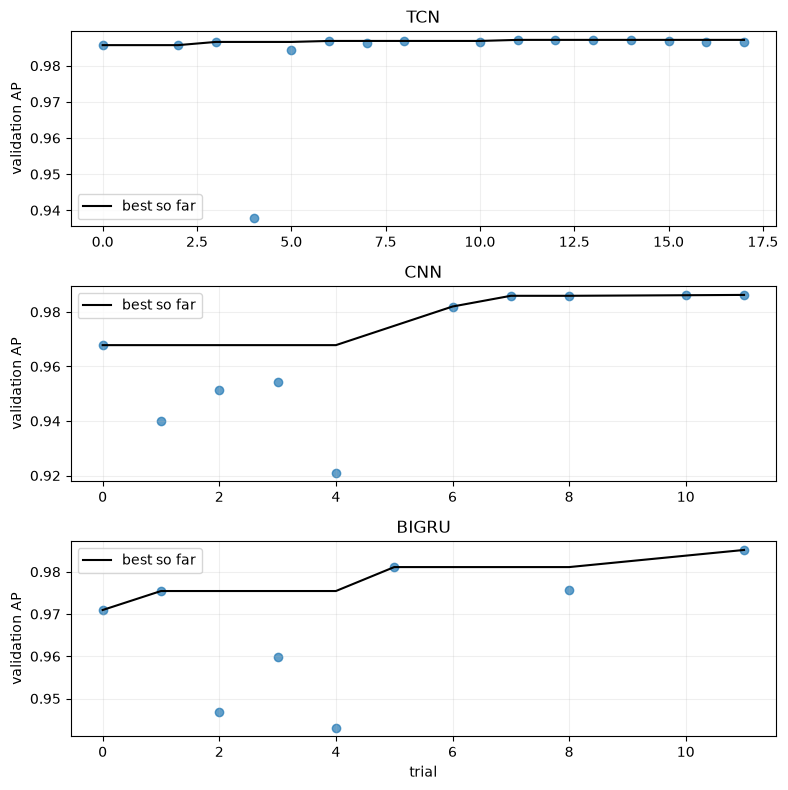

In [5]:
trial_frames = {
    architecture: burst_trial_frame(study, architecture=architecture)
    for architecture, study in studies.items()
}
display(pd.concat(
    [frame.head(8) for frame in trial_frames.values()], ignore_index=True,
).round(4))

figure, axes = plt.subplots(len(ARCHITECTURES), 1, figsize=(8, 8), sharex=False)
for axis, architecture in zip(axes, ARCHITECTURES):
    completed = trial_frames[architecture].query("state == 'COMPLETE'").sort_values("trial")
    axis.scatter(completed["trial"], completed["validation_ap"], alpha=0.7)
    axis.plot(completed["trial"], completed["validation_ap"].cummax(), color="black", label="best so far")
    axis.set(title=architecture.upper(), ylabel="validation AP")
    axis.grid(alpha=0.2); axis.legend()
axes[-1].set_xlabel("trial")
figure.tight_layout()

study_summary = pd.DataFrame({
    architecture: {
        "best_trial": study.best_trial.number,
        "best_validation_ap": study.best_value,
        "completed_trials": sum(trial.state.name == "COMPLETE" for trial in study.trials),
    }
    for architecture, study in studies.items()
}).T
display(study_summary.round(4))

### Interpretation

The comparison is based on each architecture's best validation AP, not on the final hold-out result. A broad plateau in a best-so-far curve indicates diminishing returns from additional trials within the tested search space. Parameter count remains contextual rather than an optimization target: a smaller model with comparable validation AP is evidence of greater capacity efficiency, while a larger winning model is justified only by reproducible validation improvement.

In [6]:
importance_frames = []
for architecture, study in studies.items():
    try:
        importance = optuna_parameter_importances(study)
    except (RuntimeError, ValueError):
        importance = pd.Series(dtype=float, name="importance")
    if not importance.empty:
        importance_frames.append(importance.rename(architecture))

if importance_frames:
    display(pd.concat(importance_frames, axis=1).fillna(0).round(3))
else:
    display(pd.DataFrame({"interpretation": ["More completed variation is required for parameter importance."]}))

,tcn,cnn,bigru
model.dropout,0.370,0.065,0.098
training.learning_rate,0.315,0.102,0.207
model.kernel_size,0.165,0.405,0.000
training.batch_size,0.050,0.105,0.254
training.maximum_positive_weight,0.045,0.200,0.151
training.gradient_clip_norm,0.032,0.004,0.045
model.hidden_channels,0.016,0.060,0.000
model.block_count,0.007,0.000,0.000
training.use_weight_decay,0.000,0.000,0.129
model.depth,0.000,0.058,0.000


## Final training and checkpoint export

The best configuration from each persistent study is trained once with a 60-epoch budget. Early stopping and restoration remain based exclusively on validation loss. Each architecture receives its own checkpoint containing model type, architecture parameters, best weights, optimizer configuration, positive-class weight, and train-fitted preprocessing statistics.

In [7]:
models = {}
histories = {}
checkpoint_paths = {}
model_metadata = {}

for architecture, study in studies.items():
    model_name, model_config, training_config = best_burst_model_configs(
        study, architecture=architecture,
        final_epochs=60, final_patience=12, report_every=5,
    )
    set_reproducible_seed(training_config.random_seed)
    candidate = create_burst_model(model_name, model_config)
    checkpoint_path = artifact_root() / f"best_{architecture}.pt"
    history = train_model(
        candidate, train_x, train_y, validation_x, validation_y,
        config=training_config, checkpoint_path=checkpoint_path,
        preprocessor=preprocessor,
    )
    models[architecture] = candidate
    histories[architecture] = history
    checkpoint_paths[architecture] = checkpoint_path
    model_metadata[architecture] = {
        "model_name": model_name,
        "model_config": model_config,
        "parameter_count": count_parameters(candidate),
        "best_epoch": history.best_epoch,
        "receptive_field": getattr(candidate, "receptive_field", None),
    }

pd.DataFrame(model_metadata).T

epoch   1: train loss 0.3782, validation loss 0.2385, AP 0.972
epoch   5: train loss 0.1791, validation loss 0.1691, AP 0.985
epoch  10: train loss 0.1545, validation loss 0.1645, AP 0.986
epoch  15: train loss 0.1345, validation loss 0.1684, AP 0.986
epoch  20: train loss 0.1297, validation loss 0.1721, AP 0.986
epoch  25: train loss 0.1106, validation loss 0.1815, AP 0.985
Early stopping after epoch 25.
epoch   1: train loss 0.5341, validation loss 0.3732, AP 0.931
epoch   5: train loss 0.2059, validation loss 0.2015, AP 0.980
epoch  10: train loss 0.1831, validation loss 0.1895, AP 0.983
epoch  15: train loss 0.1674, validation loss 0.1788, AP 0.984
epoch  20: train loss 0.1601, validation loss 0.1689, AP 0.986
epoch  25: train loss 0.1619, validation loss 0.1780, AP 0.984
epoch  30: train loss 0.1606, validation loss 0.1643, AP 0.986
epoch  35: train loss 0.1491, validation loss 0.1677, AP 0.986
epoch  40: train loss 0.1485, validation loss 0.1765, AP 0.984
Early stopping after epo

,model_name,model_config,parameter_count,best_epoch,receptive_field
tcn,burst_tcn,"{'input_channels': 2, 'hidden_channels': 48, '...",140161,13,505
cnn,burst_cnn,"{'input_channels': 2, 'hidden_channels': 48, '...",208513,29,85
bigru,burst_bigru,"{'input_channels': 2, 'hidden_size': 48, 'num_...",57121,48,None


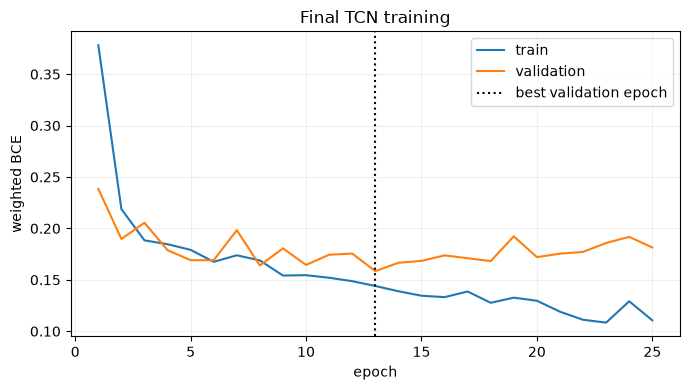

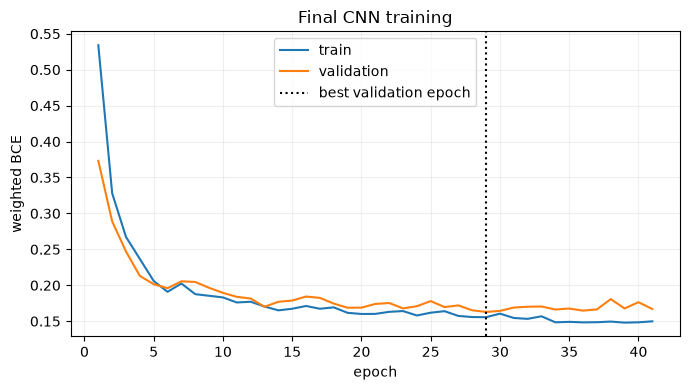

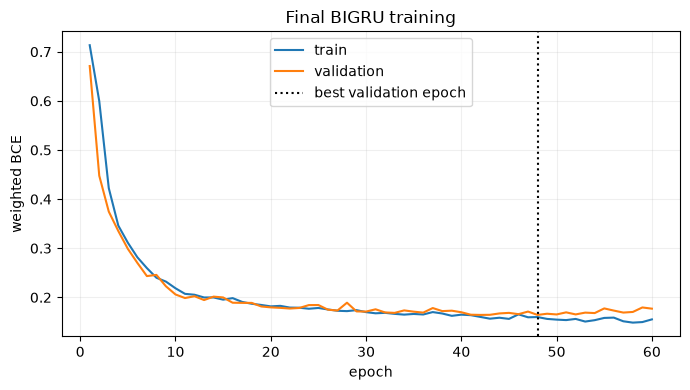

In [8]:
for architecture, history in histories.items():
    plot_training_history(history, title=f"Final {architecture.upper()} training");

### Interpretation

The dotted best-epoch line identifies the weights stored in each checkpoint. A modest gap between training and validation loss is compatible with generalization; a persistently widening gap after the marked epoch is overfitting that is excluded by best-weight restoration. Absolute loss values can vary slightly between CPU and GPU execution without changing the selected configuration, provided the minima and validation ranking remain stable.

## Freeze operating points on validation

Average precision evaluates probability ranking without choosing a threshold. Event metrics require an operating point, so each model threshold is selected by validation event F1 and is serialized before any hold-out inference. One-sample gaps are bridged and predicted events shorter than three samples are removed consistently.

In [9]:
validation_probabilities = {}
threshold_selections = {}
validation_rows = {}
for architecture, candidate in models.items():
    probabilities = predict_probabilities(candidate, validation_x)
    selection = select_threshold(splits.validation.labels, probabilities)
    validation_probabilities[architecture] = probabilities
    threshold_selections[architecture] = selection
    validation_rows[architecture] = {
        "threshold": selection.threshold, **selection.metrics.to_dict(),
    }
validation_results = pd.DataFrame(validation_rows).T
display(validation_results.round(4))

,threshold,point_precision,point_recall,point_f1,average_precision,roc_auc,event_precision,event_recall,event_f1,true_event_count,predicted_event_count,matched_event_count,burst_count_mae,center_time_mae_minutes,duration_mae_minutes
tcn,0.75,0.9744,0.8821,0.9259,0.9871,0.9877,0.9722,0.9798,0.9760,892.0,899.0,874.0,0.215,5.0000,15.3661
cnn,0.60,0.9536,0.9145,0.9336,0.9862,0.9871,0.9754,0.9787,0.9771,892.0,895.0,873.0,0.195,5.4525,13.1386
bigru,0.65,0.9637,0.8984,0.9299,0.9861,0.9868,0.9796,0.9675,0.9735,892.0,881.0,863.0,0.225,5.1159,13.3835


### Interpretation

Differences between selected thresholds are expected because probability scales are architecture- and training-dependent. The validation table supports model development but is not an unbiased estimate of final performance: both hyperparameters and thresholds were chosen on this fold. The hold-out evaluation in Notebook 03 therefore loads these frozen values without modification.

In [10]:
manifest_candidates = []
for architecture in ARCHITECTURES:
    metadata = model_metadata[architecture]
    manifest_candidates.append({
        "architecture": architecture,
        "model_name": metadata["model_name"],
        "checkpoint": checkpoint_paths[architecture].name,
        "threshold": threshold_selections[architecture].threshold,
        "validation_metrics": threshold_selections[architecture].metrics.to_dict(),
        "parameter_count": metadata["parameter_count"],
        "best_epoch": metadata["best_epoch"],
    })

manifest_path = save_holdout_manifest(
    artifact_root() / "holdout_models.json",
    candidates=manifest_candidates,
    split_config={**SPLIT_CONFIG, "archetype_seed": ARCHETYPE_SEED},
)
manifest_path

PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/burst_detection/notebooks/artifacts/holdout_models.json')

## Conclusion

The experiment produces three independently tuned and validation-selected neural candidates: a multi-scale residual TCN, a local CNN, and a bidirectional GRU. Their best weights, preprocessing parameters, and frozen validation thresholds are saved as reproducible artifacts. Architecture conclusions at this stage are necessarily provisional because validation performance participated in selection. Notebook 03 performs the first and only hold-out comparison and separates that final estimate from all model-development decisions. The benchmark remains synthetic with experimentally derived background archetypes; transfer to hand-annotated real trajectories is a separate validation problem.